# Loan Risk Analyzer — Análise Exploratória e Pré-processamento

**Projeto Integrador — Engenharia de Software para IA e Frameworks Profundos**


## 1. Configuração do Ambiente

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import seaborn as sns
from typing import List, Sequence, Tuple
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
if not (project_root / "src").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

SEED = 20

## 2. Carregamento do Dataset

In [2]:
dataset = pd.read_csv( str(project_root / "data" / "loan_data.csv") )
dataset.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
dataset.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [4]:
dataset.groupby('person_gender')['person_gender'].count()

person_gender
female    20159
male      24841
Name: person_gender, dtype: int64

## 4. Visualização Gráfica do Dataset
Gráficos para entendimento da relação entre as variáveis

### Distribuição das classes

In [5]:
print('Shape: ', dataset.shape, '\n')
print( 'Distribuição das classes:\n', dataset['loan_status'].value_counts().to_string() )

Shape:  (45000, 14) 

Distribuição das classes:
 loan_status
0    35000
1    10000


### Relação entre Renda x Valor do empréstimo x Status

<Axes: xlabel='loan_amnt', ylabel='person_income'>

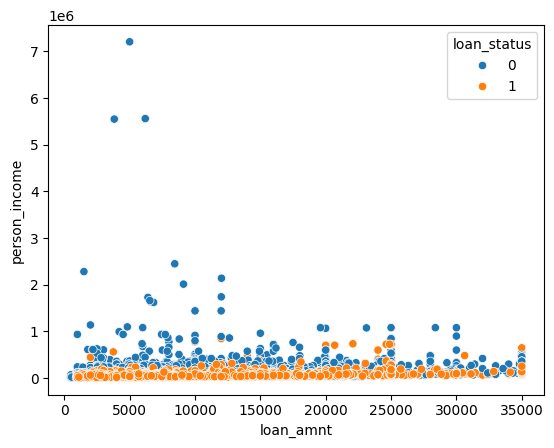

In [6]:
sns.scatterplot(x="loan_amnt", y="person_income", hue="loan_status", data=dataset)

### Taxa de default por variável categórica

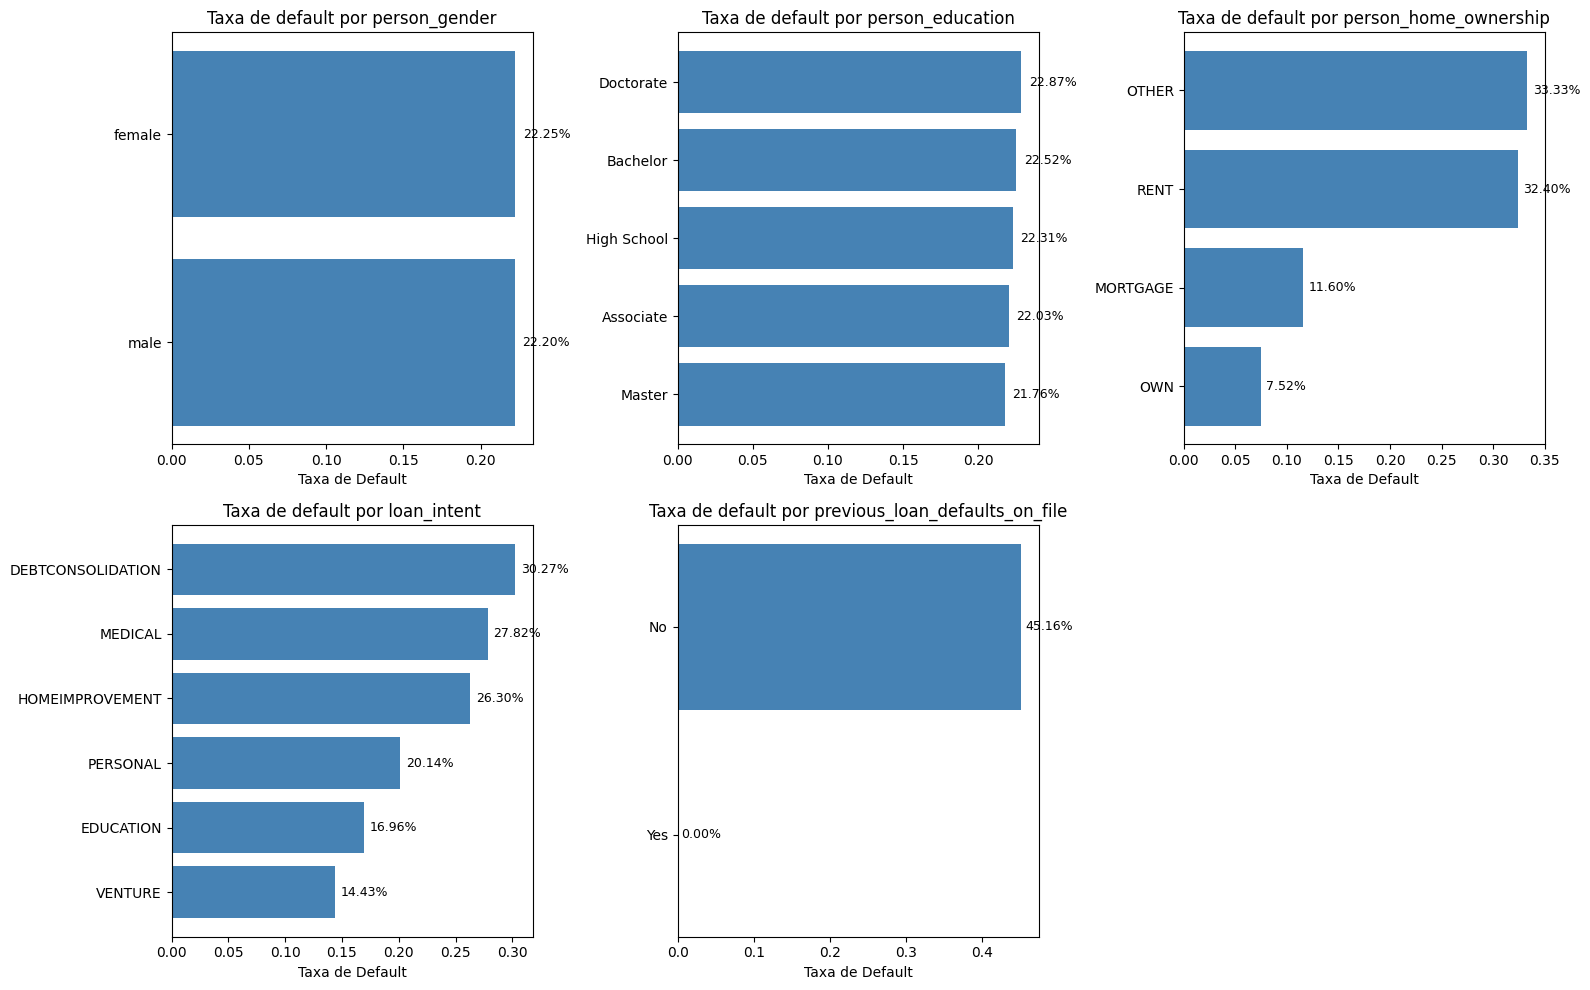

In [7]:
categorical_cols = ["person_gender", "person_education", "person_home_ownership",
                   "loan_intent", "previous_loan_defaults_on_file"]

# qtd de registros com loan_status=1
default_count = dataset['loan_status'].sum()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # universo: 
    default_rate = dataset.groupby(col)['loan_status'].mean().sort_values()
    axes[i].barh(default_rate.index.astype(str), default_rate.values, color="steelblue")
    axes[i].set_title(f"Taxa de default por {col}")
    axes[i].set_xlabel("Taxa de Default")
    for j, v in enumerate(default_rate.values):
        axes[i].text(v + 0.005, j, f"{v:.2%}", va="center", fontsize=9)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [8]:
dataset.groupby('person_gender')["loan_status"].count()

person_gender
female    20159
male      24841
Name: loan_status, dtype: int64

### Mapa de correlação entre variáveis numéricas

In [9]:
numeric_dataset = dataset.select_dtypes(include=["float64", "int64"])
numeric_dataset

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1
...,...,...,...,...,...,...,...,...,...
44995,27.0,47971.0,6,15000.0,15.66,0.31,3.0,645,1
44996,37.0,65800.0,17,9000.0,14.07,0.14,11.0,621,1
44997,33.0,56942.0,7,2771.0,10.02,0.05,10.0,668,1
44998,29.0,33164.0,4,12000.0,13.23,0.36,6.0,604,1


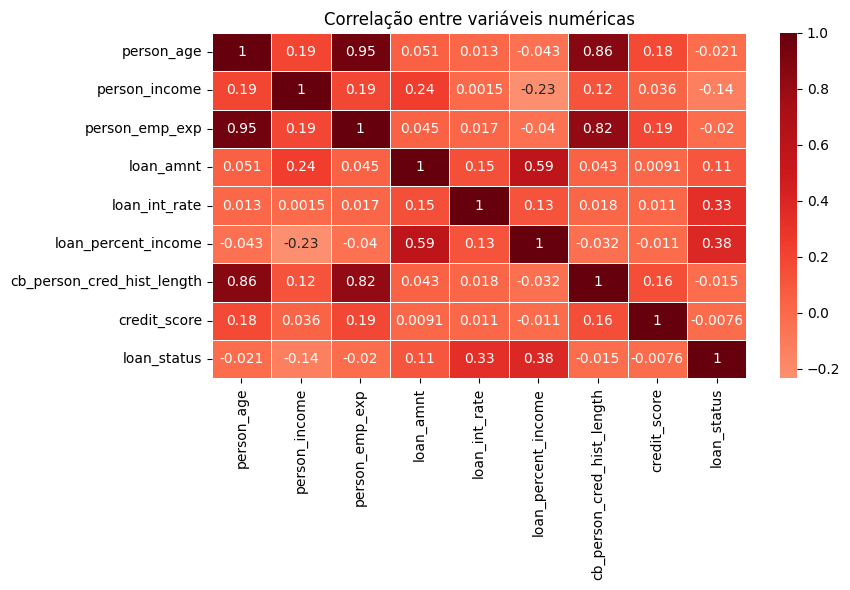

In [10]:
corr_matrix = numeric_dataset.corr()
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Reds', center=0, linewidths=0.5);
plt.title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

## 5. Pré-Processamento

In [11]:
EDUCATION_ORDER = {
    "High School": 0,
    "Associate": 1,
    "Bachelor": 2,
    "Master": 3,
    "Doctorate": 4,
}

CATEGORICAL_COLUMNS = [
    "person_gender",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file",
]

def encode_features(dataset: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """Codifica as features categóricas do dataset em valores numéricos.

    Args:
        dataset: DataFrame com os registros de empréstimos.

    Returns:
        Tupla (features codificadas, targets, nomes das features).
    """
    # Label encoding considerando a ordem natural das categorias
    dataset["person_education"] = dataset["person_education"].map(EDUCATION_ORDER)

    #One Hot Encoding
    transformer = ColumnTransformer(
        transformers = [
            ('one_hot', OneHotEncoder(sparse_output=False), CATEGORICAL_COLUMNS)
        ], remainder='passthrough' # Mantém as outras colunas (como 'Valor') sem alterações
        , verbose_feature_names_out=False
    )
    encoded_dataset = transformer.fit_transform(dataset)

    # Criando um novo DataFrame com os nomes corretos das colunas
    features = encoded_dataset[:,:-1]
    target = encoded_dataset[:,-1].astype(int)
    feature_names = transformer.get_feature_names_out()
    feature_names = feature_names[:-1]
        
    return features, target, feature_names

In [12]:
X, y, features_names = encode_features(dataset)

### 6. Separação de Conjuntos de Treinamento e Teste

In [30]:
# separa em treinamento e teste mantendo a proporção de classes entre os conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)

In [27]:
print('Qtd. de instâncias de treinamento:', len(y_train))
print('Loan Status 0:', len(y_train) - y_train.sum())
print('Loan Status 1:', y_train.sum(), '\n')

print('Qtd. de instâncias de teste:', len(y_test))
print('Loan Status 0:', len(y_test) - y_test.sum())
print('Loan Status 1:', y_test.sum())

Qtd. de instâncias de treinamento: 31500
Loan Status 0: 24500
Loan Status 1: 7000 

Qtd. de instâncias de teste: 13500
Loan Status 0: 10500
Loan Status 1: 3000
